In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Libraries loaded")

✅ Libraries loaded


In [3]:
df = pd.read_csv('../data/GlobalWeatherRepository.csv')
print(f"Shape: {df.shape}")
print(f"\nAll columns:\n{df.columns.tolist()}")

Shape: (145212, 41)

All columns:
['country', 'location_name', 'latitude', 'longitude', 'timezone', 'last_updated_epoch', 'last_updated', 'temperature_celsius', 'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph', 'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km', 'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination']


In [4]:
df['last_updated'] = pd.to_datetime(df['last_updated'])

print(f"Date range  : {df['last_updated'].min()} → {df['last_updated'].max()}")
print(f"Total span  : {(df['last_updated'].max() - df['last_updated'].min()).days} days")
print(f"Total rows  : {len(df):,}")

Date range  : 2024-05-16 01:45:00 → 2026-06-03 19:00:00
Total span  : 748 days
Total rows  : 145,212


In [5]:
print(df.dtypes)

country                                    str
location_name                              str
latitude                               float64
longitude                              float64
timezone                                   str
last_updated_epoch                       int64
last_updated                    datetime64[us]
temperature_celsius                    float64
temperature_fahrenheit                 float64
condition_text                             str
wind_mph                               float64
wind_kph                               float64
wind_degree                              int64
wind_direction                             str
pressure_mb                            float64
pressure_in                            float64
precip_mm                              float64
precip_in                              float64
humidity                                 int64
cloud                                    int64
feels_like_celsius                     float64
feels_like_fa

In [6]:
null_counts = df.isnull().sum()
has_nulls = null_counts[null_counts > 0]

if len(has_nulls) == 0:
    print("✅ Zero missing values across all columns")
else:
    print("Columns with missing values:")
    print(has_nulls)

✅ Zero missing values across all columns


In [7]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
print("✅ No duplicates" if dupes == 0 else f"⚠️ {dupes} duplicate rows found — will handle in preprocessing")

Duplicate rows: 0
✅ No duplicates


In [8]:
df.describe()

,latitude,longitude,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,145212.00,145212.00,145212.00,145212,145212.00,145212.00,145212.00,145212.00,145212.00,145212.00,145212.00,145212.00,145212.00,145212.00,145212.00,145212.00,145212.00,145212.00,145212.00,145212.00,145212.00,145212.00,145212.00,145212.00,145212.00,145212.00,145212.00,145212.00,145212.00,145212.00,145212.00
mean,19.22,21.92,1748166946.27,2025-05-25 12:05:13.368730,21.26,70.27,7.97,12.83,169.09,1014.05,29.94,0.13,0.01,66.78,39.72,22.11,71.79,9.52,5.62,3.25,11.28,18.16,446.59,57.52,14.74,10.06,23.76,47.64,1.68,2.57,50.09
min,-41.30,-175.20,1715849100.00,2024-05-16 01:45:00,-29.80,-21.60,2.20,3.60,1.00,947.00,27.96,0.00,0.00,2.00,0.00,-36.70,-34.00,0.00,0.00,0.00,2.20,3.60,-9999.00,0.00,0.00,-9999.00,0.17,-1848.15,1.00,1.00,0.00
25%,4.05,-6.84,1732092300.00,2024-11-20 04:45:00,15.78,60.38,3.80,6.10,80.00,1010.00,29.83,0.00,0.00,51.00,0.00,15.70,60.20,10.00,6.00,0.10,6.30,10.10,193.60,38.00,1.80,1.11,7.03,9.80,1.00,1.00,15.00
50%,17.25,23.24,1748161800.00,2025-05-25 11:30:00,23.70,74.60,6.70,10.80,162.00,1013.00,29.93,0.00,0.00,72.00,29.00,25.10,77.10,10.00,6.00,1.70,9.50,15.30,284.90,54.40,5.74,2.40,13.88,19.50,1.00,2.00,50.00
75%,40.40,49.88,1764227700.00,2025-11-27 13:52:30,27.90,82.30,11.00,17.60,256.00,1018.00,30.06,0.02,0.00,86.00,75.00,29.90,85.70,10.00,6.00,6.00,15.00,24.10,447.70,73.00,17.00,7.96,27.25,40.70,2.00,3.00,85.00
max,64.15,179.22,1780467300.00,2026-06-03 19:00:00,79.30,174.70,1841.20,2963.20,360.00,3006.00,88.77,42.24,1.66,100.00,100.00,81.30,178.30,32.00,19.00,16.30,1845.70,2970.40,38879.40,480.70,427.70,521.33,1614.10,6037.29,6.00,10.00,100.00
std,24.41,65.78,18655256.07,NaN,9.60,17.27,7.09,11.41,103.63,10.13,0.30,0.56,0.02,23.75,34.07,11.49,20.69,2.68,1.67,3.53,8.47,13.64,739.08,30.44,23.22,34.55,36.12,146.96,0.93,2.42,35.13


In [9]:
print(f"Unique countries : {df['country'].nunique()}")
print(f"Unique cities    : {df['location_name'].nunique()}")

if 'continent' in df.columns:
    print(f"Unique continents: {df['continent'].nunique()}")
    print(f"\nContinent breakdown:\n{df['continent'].value_counts()}")
else:
    print("\n⚠️ No continent column — will be mapped in Preprocessing")

print(f"\nTop 10 most recorded cities:")
print(df['location_name'].value_counts().head(10))

Unique countries : 211
Unique cities    : 257

⚠️ No continent column — will be mapped in Preprocessing

Top 10 most recorded cities:
location_name
Kabul           747
Bujumbura       747
N'djamena       747
Malabo          747
Asmara          747
Suva            747
Accra           747
Vatican City    747
Baghdad         747
Tokyo           747
Name: count, dtype: int64


In [10]:
key_cols = ['temperature_celsius', 'precip_mm', 'humidity', 'wind_kph', 'pressure_mb']
print("Sample stats for key weather columns:")
print(df[key_cols].describe())

Sample stats for key weather columns:
       temperature_celsius  precip_mm  humidity  wind_kph  pressure_mb
count            145212.00  145212.00 145212.00 145212.00    145212.00
mean                 21.26       0.13     66.78     12.83      1014.05
std                   9.60       0.56     23.75     11.41        10.13
min                 -29.80       0.00      2.00      3.60       947.00
25%                  15.78       0.00     51.00      6.10      1010.00
50%                  23.70       0.00     72.00     10.80      1013.00
75%                  27.90       0.02     86.00     17.60      1018.00
max                  79.30      42.24    100.00   2963.20      3006.00


In [11]:
continent_map = {
    'Afghanistan': 'Asia', 'Albania': 'Europe', 'Algeria': 'Africa', 'Andorra': 'Europe',
    'Angola': 'Africa', 'Antigua and Barbuda': 'North America', 'Argentina': 'South America',
    'Armenia': 'Asia', 'Australia': 'Oceania', 'Austria': 'Europe', 'Azerbaijan': 'Asia',
    'Bahamas': 'North America', 'Bahrain': 'Asia', 'Bangladesh': 'Asia', 'Barbados': 'North America',
    'Belarus': 'Europe', 'Belgium': 'Europe', 'Belize': 'North America', 'Benin': 'Africa',
    'Bhutan': 'Asia', 'Bolivia': 'South America', 'Bosnia and Herzegovina': 'Europe',
    'Botswana': 'Africa', 'Brazil': 'South America', 'Brunei': 'Asia', 'Bulgaria': 'Europe',
    'Burkina Faso': 'Africa', 'Burundi': 'Africa', 'Cambodia': 'Asia', 'Cameroon': 'Africa',
    'Canada': 'North America', 'Cape Verde': 'Africa', 'Central African Republic': 'Africa',
    'Chad': 'Africa', 'Chile': 'South America', 'China': 'Asia', 'Colombia': 'South America',
    'Comoros': 'Africa', 'Congo': 'Africa', 'Costa Rica': 'North America', 'Croatia': 'Europe',
    'Cuba': 'North America', 'Cyprus': 'Asia', 'Czech Republic': 'Europe', 'Czechia': 'Europe',
    'Denmark': 'Europe', 'Djibouti': 'Africa', 'Dominican Republic': 'North America',
    'Ecuador': 'South America', 'Egypt': 'Africa', 'El Salvador': 'North America',
    'Equatorial Guinea': 'Africa', 'Eritrea': 'Africa', 'Estonia': 'Europe', 'Eswatini': 'Africa',
    'Ethiopia': 'Africa', 'Fiji': 'Oceania', 'Finland': 'Europe', 'France': 'Europe',
    'Gabon': 'Africa', 'Gambia': 'Africa', 'Georgia': 'Asia', 'Germany': 'Europe',
    'Ghana': 'Africa', 'Greece': 'Europe', 'Guatemala': 'North America', 'Guinea': 'Africa',
    'Guinea-Bissau': 'Africa', 'Guyana': 'South America', 'Haiti': 'North America',
    'Honduras': 'North America', 'Hungary': 'Europe', 'Iceland': 'Europe', 'India': 'Asia',
    'Indonesia': 'Asia', 'Iran': 'Asia', 'Iraq': 'Asia', 'Ireland': 'Europe', 'Israel': 'Asia',
    'Italy': 'Europe', 'Jamaica': 'North America', 'Japan': 'Asia', 'Jordan': 'Asia',
    'Kazakhstan': 'Asia', 'Kenya': 'Africa', 'Kosovo': 'Europe', 'Kuwait': 'Asia',
    'Kyrgyzstan': 'Asia', 'Laos': 'Asia', 'Latvia': 'Europe', 'Lebanon': 'Asia',
    'Lesotho': 'Africa', 'Liberia': 'Africa', 'Libya': 'Africa', 'Liechtenstein': 'Europe',
    'Lithuania': 'Europe', 'Luxembourg': 'Europe', 'Madagascar': 'Africa', 'Malawi': 'Africa',
    'Malaysia': 'Asia', 'Maldives': 'Asia', 'Mali': 'Africa', 'Malta': 'Europe',
    'Mauritania': 'Africa', 'Mauritius': 'Africa', 'Mexico': 'North America', 'Moldova': 'Europe',
    'Monaco': 'Europe', 'Mongolia': 'Asia', 'Montenegro': 'Europe', 'Morocco': 'Africa',
    'Mozambique': 'Africa', 'Myanmar': 'Asia', 'Namibia': 'Africa', 'Nepal': 'Asia',
    'Netherlands': 'Europe', 'New Zealand': 'Oceania', 'Nicaragua': 'North America',
    'Niger': 'Africa', 'Nigeria': 'Africa', 'North Korea': 'Asia', 'North Macedonia': 'Europe',
    'Norway': 'Europe', 'Oman': 'Asia', 'Pakistan': 'Asia', 'Panama': 'North America',
    'Papua New Guinea': 'Oceania', 'Paraguay': 'South America', 'Peru': 'South America',
    'Philippines': 'Asia', 'Poland': 'Europe', 'Portugal': 'Europe', 'Qatar': 'Asia',
    'Romania': 'Europe', 'Russia': 'Europe', 'Rwanda': 'Africa', 'Saudi Arabia': 'Asia',
    'Senegal': 'Africa', 'Serbia': 'Europe', 'Sierra Leone': 'Africa', 'Singapore': 'Asia',
    'Slovakia': 'Europe', 'Slovenia': 'Europe', 'Solomon Islands': 'Oceania', 'Somalia': 'Africa',
    'South Africa': 'Africa', 'South Korea': 'Asia', 'South Sudan': 'Africa', 'Spain': 'Europe',
    'Sri Lanka': 'Asia', 'Sudan': 'Africa', 'Suriname': 'South America', 'Sweden': 'Europe',
    'Switzerland': 'Europe', 'Syria': 'Asia', 'Taiwan': 'Asia', 'Tajikistan': 'Asia',
    'Tanzania': 'Africa', 'Thailand': 'Asia', 'Timor-Leste': 'Asia', 'Togo': 'Africa',
    'Trinidad and Tobago': 'North America', 'Tunisia': 'Africa', 'Turkey': 'Asia',
    'Turkmenistan': 'Asia', 'Uganda': 'Africa', 'Ukraine': 'Europe',
    'United Arab Emirates': 'Asia', 'United Kingdom': 'Europe',
    'United States of America': 'North America', 'United States': 'North America',
    'Uruguay': 'South America', 'Uzbekistan': 'Asia', 'Vatican City': 'Europe',
    'Venezuela': 'South America', 'Vietnam': 'Asia', 'Yemen': 'Asia',
    'Zambia': 'Africa', 'Zimbabwe': 'Africa',
    'Democratic Republic of the Congo': 'Africa', "Côte d'Ivoire": 'Africa',
    'Sao Tome and Principe': 'Africa', 'Palestine': 'Asia',
}

month_to_season = {
    12: 'Winter', 1: 'Winter',  2: 'Winter',
     3: 'Spring', 4: 'Spring',  5: 'Spring',
     6: 'Summer', 7: 'Summer',  8: 'Summer',
     9: 'Autumn', 10: 'Autumn', 11: 'Autumn',
}

df['continent'] = df['country'].map(continent_map).fillna('Other')
df['season']    = df['last_updated'].dt.month.map(month_to_season)

print("Continent breakdown:")
print(df['continent'].value_counts())
unmapped = df[df['continent'] == 'Other']['country'].unique()
print(f"\nUnmapped → 'Other' ({(df['continent']=='Other').mean()*100:.1f}%):")
print(unmapped if len(unmapped) else "None ✅")
print(f"\nSeason breakdown:")
print(df['season'].value_counts())

Continent breakdown:
continent
Asia             36180
Africa           35487
Europe           32372
Other            15932
North America    13346
South America     8912
Oceania           2983
Name: count, dtype: int64

Unmapped → 'Other' (11.0%):
<StringArray>
[               'Brunei Darussalam',     'Democratic Republic of Congo',
                         'Dominica',                        'Swaziland',
                     'Fiji Islands',                          'Grenada',
                         'Kiribati',                      'Kyrghyzstan',
                 'Marshall Islands',                       'Micronesia',
                        'Macedonia',                            'Palau',
            'Saint Kitts and Nevis',                      'Saint Lucia',
 'Saint Vincent and the Grenadines',                            'Samoa',
                       'San Marino',               'Seychelles Islands',
                            'Tonga',                           'Tuvalu',
         

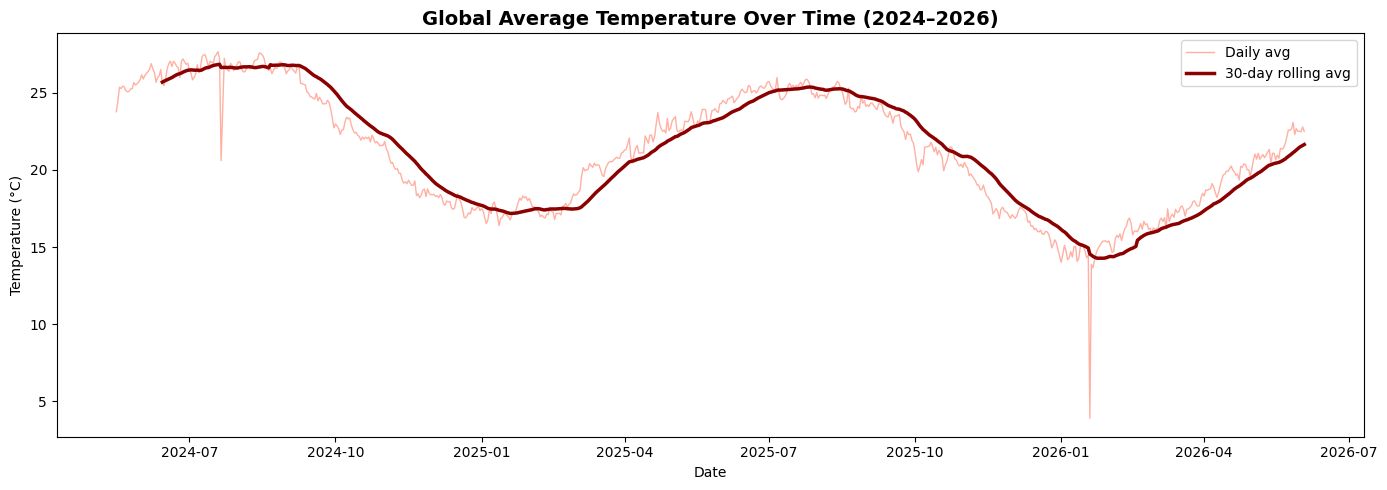

✅ Saved: 01_global_temp_trend.png


In [12]:
daily_temp = (df.groupby(df['last_updated'].dt.date)['temperature_celsius']
                .mean().reset_index())
daily_temp.columns = ['date', 'avg_temp']
daily_temp['date'] = pd.to_datetime(daily_temp['date'])

plt.figure(figsize=(14, 5))
plt.plot(daily_temp['date'], daily_temp['avg_temp'],
         color='tomato', linewidth=1, alpha=0.5, label='Daily avg')
plt.plot(daily_temp['date'], daily_temp['avg_temp'].rolling(30).mean(),
         color='darkred', linewidth=2.5, label='30-day rolling avg')
plt.title('Global Average Temperature Over Time (2024–2026)',
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/01_global_temp_trend.png', dpi=150)
plt.show()
print("✅ Saved: 01_global_temp_trend.png")

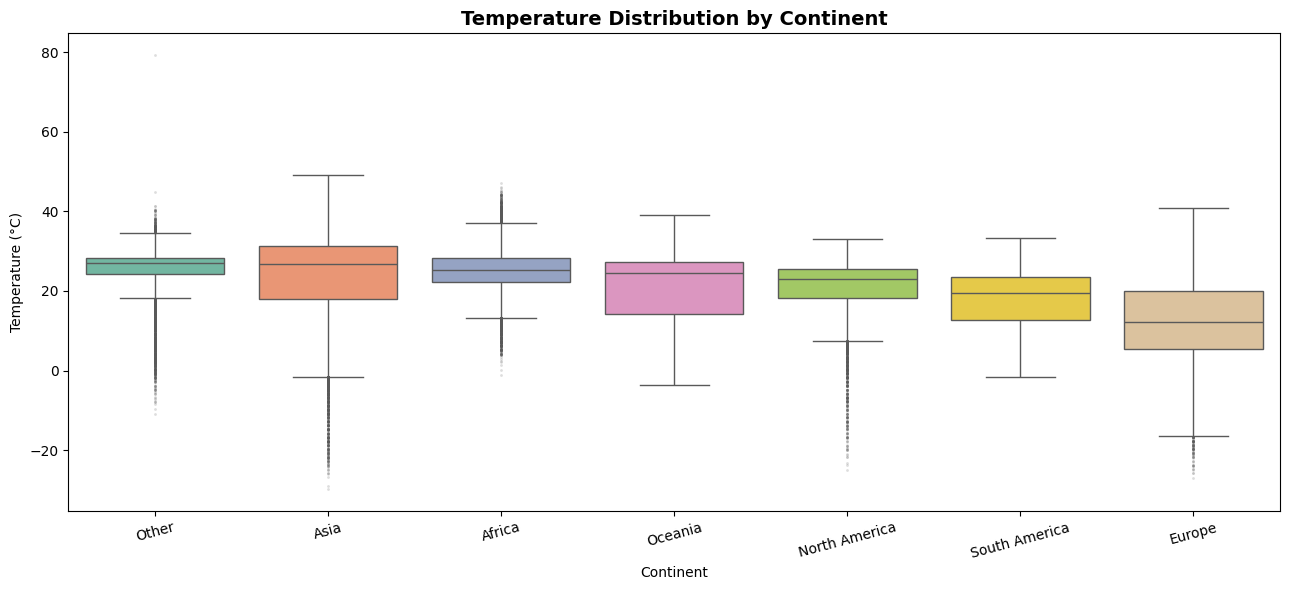

✅ Saved: 02_temp_by_continent.png


In [13]:
continent_order = (df.groupby('continent')['temperature_celsius']
                     .median()
                     .sort_values(ascending=False)
                     .index.tolist())

plt.figure(figsize=(13, 6))
sns.boxplot(data=df, x='continent', y='temperature_celsius',
            order=continent_order, palette='Set2',
            flierprops=dict(marker='o', markersize=1, alpha=0.2))
plt.title('Temperature Distribution by Continent', fontsize=14, fontweight='bold')
plt.xlabel('Continent')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../outputs/02_temp_by_continent.png', dpi=150)
plt.show()
print("✅ Saved: 02_temp_by_continent.png")

✅ Saved: 03_choropleth_temp.png


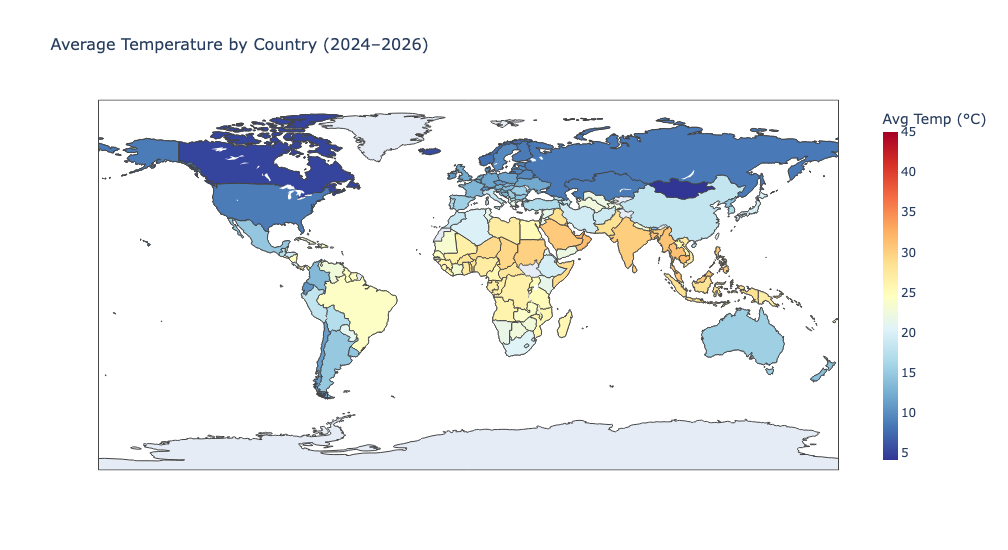

In [14]:
import plotly.express as px

country_temp = (df.groupby('country')['temperature_celsius']
                  .mean().reset_index()
                  .rename(columns={'temperature_celsius': 'avg_temp'}))

fig = px.choropleth(
    country_temp,
    locations='country',
    locationmode='country names',
    color='avg_temp',
    color_continuous_scale='RdYlBu_r',
    title='Average Temperature by Country (2024–2026)',
    labels={'avg_temp': 'Avg Temp (°C)'},
    width=1000, height=550
)
fig.update_layout(title_font_size=16, coloraxis_colorbar=dict(thickness=15))
try:
    fig.write_image('../outputs/03_choropleth_temp.png', scale=2)
    print("✅ Saved: 03_choropleth_temp.png")
except Exception as e:
    print(f"⚠️ PNG save failed: {e} — showing inline only")
fig.show()

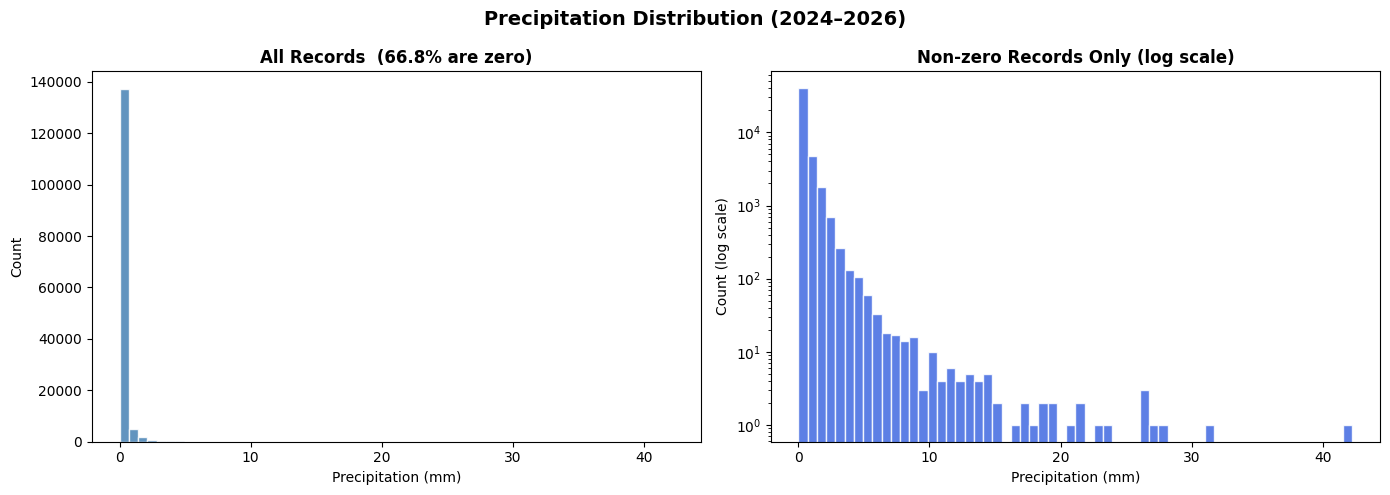

✅ Saved: 04_precip_histogram.png
Zero precip records: 97,063 / 145,212  (66.8%)


In [15]:
precip_nonzero = df[df['precip_mm'] > 0]['precip_mm']
zero_pct = (df['precip_mm'] == 0).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['precip_mm'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title(f'All Records  ({zero_pct:.1f}% are zero)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Precipitation (mm)')
axes[0].set_ylabel('Count')

axes[1].hist(precip_nonzero, bins=60, color='royalblue', edgecolor='white', alpha=0.85)
axes[1].set_title('Non-zero Records Only (log scale)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Precipitation (mm)')
axes[1].set_yscale('log')
axes[1].set_ylabel('Count (log scale)')

plt.suptitle('Precipitation Distribution (2024–2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/04_precip_histogram.png', dpi=150)
plt.show()
print(f"✅ Saved: 04_precip_histogram.png")
print(f"Zero precip records: {(df['precip_mm']==0).sum():,} / {len(df):,}  ({zero_pct:.1f}%)")